In [1]:
import pandas as pd
import numpy as np
import re
import plotly.express as px
from plotly.subplots import make_subplots
import plotly.graph_objects as go
from functools import reduce

In [30]:
cases = ['noemissionscap', '30pct', '60pct', '90pct']
flow_dfs = {}

for case in cases:
    flows = pd.read_csv('results/' + case + '/results/flows.csv')
    flow_dfs[case] = flows

In [31]:
def get_flow_sums_by_tech(
    flow_df,
    include_keywords=None,     # list of substrings to keep column names
    drop_techs=None            # list of tech names to drop
):
    """
    Build a Region × Technology CO₂ emissions table (Region = rows).
    """

    # --- 1. Select columns ---
    if include_keywords is not None:
        co2_cols = [
            c for c in flow_df.columns
            if any(kw in c for kw in include_keywords)
        ]
    else:
        # Match any column containing both "co2" and "edge" regardless of order/position
        co2_cols = [
            c for c in flow_df.columns
            if "co2" in c.lower() and "edge" in c.lower()
        ]

    # --- Region sort ---
    def region_sort_key(name):
        match = re.search(r"Region(\d+)", name)
        return int(match.group(1)) if match else 999

    co2_cols = sorted(co2_cols, key=region_sort_key)

    # --- 2. Sum flows across time ---
    co2_sums = flow_df[co2_cols].sum()

    # --- 3. Extract Region and Technology names in one pass ---
    full_pattern = re.compile(r"Region\d+([A-Za-z]+)_(.*)")

    rows = []
    for col, val in co2_sums.items():
        m = full_pattern.search(col)
        if m:
            rows.append({"Region": m.group(1), "Technology": m.group(2), "Value": val})

    df = pd.DataFrame(rows)

    co2_by_region_tech = df.pivot_table(
        index="Region",
        columns="Technology",
        values="Value",
        aggfunc="sum"
    )

    co2_by_region_tech = co2_by_region_tech[
        sorted(co2_by_region_tech.columns, key=lambda x: x.lower())
    ]

    # --- 4. Drop unwanted technologies ---
    if drop_techs is not None:
        existing = [t for t in drop_techs if t in co2_by_region_tech.columns]
        co2_by_region_tech = co2_by_region_tech.drop(columns=existing)

    return co2_by_region_tech

In [32]:
co2_by_region_tech_dict = {}
co2_all_china_by_tech = pd.DataFrame()

for case in cases:
    co2_by_region_tech = get_flow_sums_by_tech(
    flow_dfs[case],
    include_keywords=["co2_edge", "co2_emissions_edge"],
    drop_techs=["nuclear_co2_edge", "oxyfuelcement_co2_emissions_edge"]
)   
    co2_by_region_tech_dict[case] = co2_by_region_tech
    co2_all_china_by_tech[case] = co2_by_region_tech.sum()

In [33]:
co2_all_china_by_tech

,noemissionscap,30pct,60pct,90pct
Technology,,,,
aluminum_smelting_co2_edge,2.171863e+06,2.171849e+06,2.171849e+06,2.171877e+06
bfbof_co2_edge,5.252406e+07,5.252406e+07,5.252534e+07,1.017118e+03
bfbofccs_co2_edge,4.976907e+01,7.116402e+01,1.336485e+02,3.979857e+02
bfbofccs_retrofit_co2_edge,1.220523e+02,1.447148e+02,2.790245e+02,4.518357e+02
coal_co2_edge,2.816453e+08,1.077555e+08,8.513339e+06,4.602296e+03
drieaf_co2_edge,5.418968e+00,9.333504e+00,1.310211e+01,1.206885e+06
drieaf_retrofit_co2_edge,7.439222e+00,1.167940e+01,2.536687e+01,3.112154e+05
gasdri_co2_edge,5.163349e+01,7.711581e+01,1.470938e+02,4.317524e+02
gasdriccs_co2_edge,4.207655e+01,6.063542e+01,1.083373e+02,3.582800e+02


# Plot CO2 Emissions by Region and Tech

In [34]:
scenario_map = {
    "noemissionscap": "No Emissions Policy",
    "30pct": "30% Emissions Reduction",
    "60pct": "60% Emissions Reduction",
    "90pct": "90% Emissions Reduction"
}

In [35]:
# Make Name Map
tech_name_map = {
    # Cement
    "oxyfuelcement_retrofit_co2_emissions_edge": "Oxyfuel Cement Retrofit",
    "tradcement_co2_emissions_edge": "Traditional Cement",

    # Steel (BF-BOF and Scrap EAF)
    "bfbof_co2_edge": "BF-BOF",
    "bfbofccs_co2_edge": "BF-BOF-CCS",
    "bfbofccs_retrofit_co2_edge": "BF-BOF-CCS Retrofit",
    "scrapeaf56_co2_edge": "Scrap EAF 56%",
    "scrapeaf100_co2_edge": "Scrap EAF 100%",
    "scrapeaf100_retrofit_co2_edge": "Scrap EAF 100% Retrofit",

    # Steel (DRI Routes)
    "drieaf_co2_edge": "DRI-EAF",
    "drieaf_retrofit_co2_edge": "DRI-EAF Retrofit",
    "gasdri_co2_edge": "Gas DRI",
    "gasdriccs_co2_edge": "Gas DRI with CCS",
    "h2dri_co2_edge": "H2 DRI",

    # Aluminum
    "aluminum_smelting_co2_edge": "Aluminum Smelting",

    # Power & Energy
    "coal_co2_edge": "Coal Power",
    "naturalgas_power_co2_edge": "Natural Gas Power",
}

In [98]:
custom_color_map = {
    "Oxyfuel Cement Retrofit": "#ff9d9a",
    "Traditional Cement": "#e15759",

    # Steel - Primary & Scrap
    "BF-BOF": "#1f77b4",
    "BF-BOF-CCS": "#0ee3ff",
    "BF-BOF-CCS Retrofit": "#aec7e8",
    "Scrap EAF 56%": "#38a938",
    "Scrap EAF 100%": "#6acaa2",
    "Scrap EAF 100% Retrofit": "#98df8a",

    # Steel - DRI Routes
    "DRI-EAF": "#9467bd",
    "DRI-EAF Retrofit": "#c5b0d5",
    "Gas DRI": "#8c564b",
    "Gas DRI with CCS": "#e377c2",
    "H2 DRI": "#17becf",

    # Aluminum
    "Aluminum Smelting": "#bbbbb2",

    # Power
    "Natural Gas Power": "#eb7a23",
    "Coal Power": "#4a5568",

    "Hydropower": "#3e6496",
    "Solar PV (Centralized)":"#fbb04e",
    "Solar PV (Distributed)": "#f1ce63",
    "Wind (Offshore)": "#638fbb",
    "Wind (Onshore)": "#90bfe2",
    "Battery Storage": "#9f6490",
    "Nuclear": "#3c8782",
    "Pumped Hydro Storage": "#75afa7"
}


In [99]:
import plotly.express as px
import pandas as pd

def plot_stacked_bar(
    df,
    scenario_map=None,      # maps scenario/column names to pretty names
    name_map=None,          # maps technology names (index) to pretty names
    color_map=None,         # maps pretty tech names --> colors
    title_name="none",
    xaxis_name="none",
    yaxis_name="none",
    width=1200,
    height=600,
):
    """
    Create a stacked bar plot where:
      - each COLUMN of df becomes a bar (scenario)
      - each ROW/index becomes a stacked segment (technology)

    New features:
      • scenario_map: dict mapping df column → label
      • title_name, xaxis_name, yaxis_name: optional labels (default = "none")
    """

    # --- Apply scenario_map to rename incoming bar labels ---
    if scenario_map:
        df = df.rename(index=scenario_map)

    # Transpose so that each scenario becomes one bar
    df = df.T

    # Ensure the index has a name
    if not df.index.name:
        df = df.copy()
        df.index.name = "Category"

    row_label = df.index.name

    # Convert to long format
    df_long = df.reset_index().melt(
        id_vars=row_label,
        var_name="Scenario",
        value_name="Value"
    )

    # --- Apply name_map to legend entries (index entries) ---
    display_col = row_label + "_Display"

    if name_map:
        df_long[display_col] = df_long[row_label].map(lambda x: name_map.get(x, x))
    else:
        df_long[display_col] = df_long[row_label]

    # --- If color_map is provided, remap using the display names ---
    if color_map and name_map:
        color_map = {name_map.get(k, k): v for k, v in color_map.items()}

    fig = px.bar(
        df_long,
        x="Scenario",
        y="Value",
        color=display_col,
        title=None if title_name == "none" else title_name,
        labels={
            "Scenario": xaxis_name if xaxis_name != "none" else "Scenario",
            "Value": yaxis_name if yaxis_name != "none" else "Value",
            display_col: row_label
        },
        color_discrete_map=color_map,
    )

    fig.update_layout(
        barmode="stack",
        template="plotly_white",
        width=width,
        height=height,
        margin=dict(l=60, r=60, t=80, b=80),
        legend=dict(traceorder="reversed")
    )

    fig.update_xaxes(tickangle=-45)
    return fig


In [100]:
plot_stacked_bar(
    df = co2_all_china_by_tech.T,
    scenario_map=scenario_map,
    name_map=tech_name_map,
    color_map=custom_color_map,
    title_name="Emissions by Source for 4 Emissions Scenarios",
    xaxis_name="Emissions Scenario",
    yaxis_name="National CO2 Emissions (Tonnes)",
    width=700)

In [47]:
from plotly.subplots import make_subplots

def plot_scenario_subplots(
    co2_dict,
    scenario_map,            # dict: scenario_key -> display label
    name_map=None,
    color_map=None,
    ymax=30e6,
    ncols=None,
    title_prefix="",
    xaxis_name="none",
    yaxis_name="none",
    width=2500
):
    keys = list(co2_dict.keys())
    n = len(keys)

    if ncols is None:
        ncols = n

    # ---- Create subplot grid ----
    fig = make_subplots(
        rows=1,
        cols=ncols,
        subplot_titles=[f"{title_prefix}{scenario_map[k]}" for k in keys],
        horizontal_spacing=0.05,
    )

    # ---- Loop through scenarios ----
    for col_idx, key in enumerate(keys, start=1):
        df = co2_dict[key]

        # Build stacked bar chart WITHOUT axis titles (we add them manually)
        subfig = plot_stacked_bar(
            df,
            scenario_map=scenario_map,
            name_map=name_map,
            color_map=color_map,
            title_name="none",
            xaxis_name="none",
            yaxis_name="none"
        )

        # Add each trace into its subplot
        for trace in subfig.data:
            trace.showlegend = (col_idx == 1)   # only show legend in first
            fig.add_trace(trace, row=1, col=col_idx)

        # Set y-range
        fig.update_yaxes(range=[0, ymax], row=1, col=col_idx)

    # ---- Add AXIS TITLES manually (important) ----
    # y-axis title only on the first subplot
    if yaxis_name != "none":
        fig.update_yaxes(title_text=yaxis_name, row=1, col=1)

    # x-axis titles on each subplot
    if xaxis_name != "none":
        for col_idx in range(1, ncols+1):
            fig.update_xaxes(title_text=xaxis_name, row=1, col=col_idx)

    # ---- Layout ----
    fig.update_layout(
        template="plotly_white",
        barmode="stack",
        height=650,
        width=width,
        legend_title="Category",
        margin=dict(l=40, r=40, t=80, b=80),
        legend=dict(traceorder="reversed")
    )

    fig.update_xaxes(tickangle=-45)

    return fig


In [71]:
co2_by_region_tech_dict['30pct']

Technology,aluminum_smelting_co2_edge,bfbof_co2_edge,bfbofccs_co2_edge,bfbofccs_retrofit_co2_edge,coal_co2_edge,drieaf_co2_edge,drieaf_retrofit_co2_edge,gasdri_co2_edge,gasdriccs_co2_edge,h2dri_co2_edge,naturalgas_power_co2_edge,oxyfuelcement_retrofit_co2_emissions_edge,scrapeaf100_co2_edge,scrapeaf100_retrofit_co2_edge,scrapeaf56_co2_edge,tradcement_co2_emissions_edge
Region,,,,,,,,,,,,,,,,
Anhui,87626.284707,1.864075e+06,2.411744,5.157126,5.974847e+06,0.333244,0.407769,2.652847,2.086601,0.0,1.768848e+06,1.946930,1.017714,12457.897766,2967.735537,3.397220e+06
Beijing,37.494870,3.204917e+06,2.411968,5.307928,2.452072e+02,0.335472,0.367725,2.664491,2.101077,0.0,1.910287e+06,1.627938,0.994511,9705.242450,2115.873539,6.649989e+04
Chongqing,20386.548310,6.545482e+05,2.427050,4.597467,7.299343e+05,0.327418,0.402194,2.664854,2.100623,0.0,1.667188e+06,1.718413,1.030948,1495.713223,25000.841525,1.538564e+06
Fujian,33896.480012,1.450504e+06,2.422063,4.950090,2.185967e+06,0.272297,0.346391,2.649494,2.081351,0.0,2.171595e+06,1.679600,1.037436,23303.477541,33308.384078,2.299334e+06
Gansu,161543.173583,5.745472e+05,2.416393,4.480268,2.596335e+06,0.346321,0.396855,2.661795,2.093086,0.0,8.334915e+05,1.718374,1.003498,1483.374311,22391.749713,1.139732e+06
Guangdong,22240.291349,1.662826e+06,2.417863,5.006619,1.472257e+07,0.249876,0.534345,2.645578,2.080109,0.0,4.206124e+06,1.860226,1.044287,4837.443945,292144.103488,4.054769e+06
Guangxi,165158.341168,2.176016e+06,2.418879,5.182560,2.876467e+06,0.276720,0.552897,2.654420,2.085166,0.0,2.017369e+06,1.760934,1.000698,135.083313,476951.191594,2.920493e+06
Guizhou,63637.007157,2.012097e+05,2.415767,5.201343,4.015884e+06,0.340041,0.494024,2.655761,2.086305,0.0,5.688769e+05,1.796825,1.025110,110.987005,217429.785629,2.629634e+06
Hainan,38.874038,NaN,NaN,NaN,3.271606e+05,NaN,NaN,NaN,NaN,NaN,2.660248e+05,1.454624,NaN,NaN,NaN,4.398174e+05


In [48]:
plot_scenario_subplots(
    co2_by_region_tech_dict,
    scenario_map=scenario_map,
    name_map=tech_name_map,
    color_map=custom_color_map,
    ymax=30e6,
    xaxis_name='Province',
    yaxis_name='CO2 Emissions (Tonnes)',
    width=2000
)

In [49]:
flows = flow_dfs['noemissionscap']
co2_cols = [c for c in flows.columns if (c.endswith("co2_edge") or c.endswith("co2_emissions_edge"))]

region_groups = {}
for col in flows[co2_cols].columns:
    region = col.split("_")[0]   # e.g. Region1Beijing
    region_groups.setdefault(region, []).append(col)

# Now sum per region
region_sums = pd.DataFrame()

for region, cols in region_groups.items():
    region_sums[region] = flows[cols].sum(axis=1)

region_sums.sum().sort_values(ascending=False)


Region15Shandong        3.391828e+07
Region10Jiangsu         3.087432e+07
Region19Guangdong       3.022159e+07
Region3Hebei            2.878345e+07
Region5Innermongolia    2.569015e+07
Region12Anhui           2.226552e+07
Region4Shanxi           2.018001e+07
Region16Henan           1.921985e+07
Region31Xinjiang        1.762173e+07
Region11Zhejiang        1.741918e+07
Region27Shaanxi         1.455082e+07
Region20Guangxi         1.369436e+07
Region17Hubei           1.262599e+07
Region13Fujian          1.148285e+07
Region24Guizhou         1.119495e+07
Region14Jiangxi         1.085898e+07
Region18Hunan           9.793868e+06
Region6Liaoning         9.338078e+06
Region28Gansu           8.785075e+06
Region23Sichuan         8.093131e+06
Region30Ningxia         7.373696e+06
Region25Yunnan          6.785415e+06
Region7Jilin            6.661878e+06
Region22Chongqing       5.612729e+06
Region9Shanghai         5.349155e+06
Region8Heilongjiang     5.062444e+06
Region2Tianjin          4.313282e+06
R

# Plot Cement Capacity Decisions

In [77]:
# Load Capacity Data

cases = ['noemissionscap', '30pct', '60pct', '90pct']
capacity_dfs = {}

for case in cases:
    capacity = pd.read_csv('results/' + case + '/results/capacity.csv')
    capacity["region_name"] = (capacity["resource_id"].astype(str).str.extract(r"Region\d+([A-Za-z]+)", expand=False))
    capacity_dfs[case] = capacity

In [101]:
def get_capacity_by_sector(capacity_dfs, cases):
    """
    Extract capacity dataframes for electricity, cement, steel, and aluminum.

    Parameters
    ----------
    capacity_dfs : dict[str, pd.DataFrame]
        Dict of case name → raw capacity CSV DataFrame (with region_name column).
    cases : list[str]
        Cases to extract; must be keys in capacity_dfs.

    Returns
    -------
    elec_dict, cement_dict, steel_dict, aluminum_dict : dict[str, pd.DataFrame]
        Each dict is keyed by case name. Each DataFrame is indexed by region_name
        with display-name columns, ready to pass directly to plot_province_pies.
    """

    # ── Suffix-based extractor (cement / steel / aluminum) ──────────────────
    def _extract_by_suffix(df, suffix_to_display):
        tmp = df[["region_name", "resource_id", "capacity"]].copy()

        def match(rid):
            for suf, name in suffix_to_display.items():
                if str(rid).endswith(suf):
                    return name
            return None

        tmp["tech"] = tmp["resource_id"].map(match)
        tmp = tmp[tmp["tech"].notna()]
        result = (
            tmp.groupby(["region_name", "tech"], as_index=False)["capacity"].sum()
            .pivot(index="region_name", columns="tech", values="capacity")
            .fillna(0)
            .reindex(columns=list(suffix_to_display.values()))
        )
        result.columns.name = None
        return result

    # ── Sector definitions ───────────────────────────────────────────────────
    _elec_rename = {
        "coal":             "Coal Power",
        "Hydropower":       "Hydropower",
        "PV_Central":       "Solar PV (Centralized)",
        "PV_Distribution":  "Solar PV (Distributed)",
        "Wind_Offshore":    "Wind (Offshore)",
        "Wind_Onshore":     "Wind (Onshore)",
        "battery":          "Battery Storage",
        "naturalgas_power": "Natural Gas Power",
        "nuclear":          "Nuclear",
        "pumpedhydro":      "Pumped Hydro Storage",
    }
    _elec_techs = set(_elec_rename.keys())

    _cement_suffixes = {
        "_tradcement":             "Traditional Cement",
        "_oxyfuelcement_retrofit": "Oxyfuel Cement Retrofit",
    }

    _steel_suffixes = {
        "_bfbof":                  "BF-BOF",
        "_bfbofccs_retrofit":      "BF-BOF-CCS Retrofit",
        "_bfbofccs":               "BF-BOF-CCS",
        "_scrapeaf56":             "Scrap EAF 56%",
        "_scrapeaf100_retrofit":   "Scrap EAF 100% Retrofit",
        "_scrapeaf100":            "Scrap EAF 100%",
    }

    _aluminum_suffixes = {
        "_aluminum_smelting": "Aluminum Smelting",
    }

    # ── Build one df per case per sector ────────────────────────────────────
    elec_dict, cement_dict, steel_dict, aluminum_dict = {}, {}, {}, {}

    for case in cases:
        df = capacity_dfs[case]

        # Electricity
        df_e = df.copy()
        df_e["technology"] = df_e["resource_id"].str.split("_", n=1).str[1]
        df_e = df_e[df_e["technology"].isin(_elec_techs)]
        df_e = df_e[~df_e["component_id"].str.endswith("inflow_edge")]
        df_e = df_e[~df_e["component_id"].str.contains("storage", na=False)]
        elec_df = (
            df_e.pivot(index="region_name", columns="technology", values="capacity")
            .rename(columns=_elec_rename)
        )
        elec_df.columns.name = None
        elec_dict[case] = elec_df

        cement_dict[case]   = _extract_by_suffix(df, _cement_suffixes)
        steel_dict[case]    = _extract_by_suffix(df, _steel_suffixes)
        aluminum_dict[case] = _extract_by_suffix(df, _aluminum_suffixes)

    return elec_dict, cement_dict, steel_dict, aluminum_dict

In [ ]:
def consolidate_capacity(sector_dict):
    """
    Consolidate a sector capacity dict into a single DataFrame.

    Parameters
    ----------
    sector_dict : dict[str, pd.DataFrame]
        Output from get_capacity_by_sector — keyed by case name, each value
        is a region × technology DataFrame.

    Returns
    -------
    pd.DataFrame
        Technology × case DataFrame (national totals), ready for plot_stacked_bar.
    """
    return pd.DataFrame(
        {case: df.sum() for case, df in sector_dict.items()}
    )


In [102]:
elec_df, cement_df, steel_df, aluminum_df = get_capacity_by_sector(capacity_dfs, cases)

In [105]:
elec_df

{'noemissionscap':                Hydropower  Solar PV (Centralized)  Solar PV (Distributed)  \
 region_name                                                                 
 Anhui              5071.0                0.715221            7.001147e-01   
 Beijing             892.0                0.994038            9.731744e-01   
 Chongqing          5834.0                0.842323            8.031022e-01   
 Fujian             8922.0                0.847372            7.080874e-01   
 Gansu              5514.0                0.740780           -5.684342e-14   
 Guangdong         12682.0                0.686108            7.378423e-01   
 Guangxi           15330.0                0.637180           -4.547474e-13   
 Guizhou           16735.0                0.688938           -8.526513e-14   
 Hainan             1002.0                0.654456            8.987988e-01   
 Hebei              5570.0                0.789366            7.017125e-01   
 Heilongjiang       1296.0                0.73

In [224]:
plot_stacked_bar(
    steel_capacity_all_china.T,
    scenario_map=scenario_map,
    name_map=steel_name_map,
    color_map=custom_color_map,
    title_name = "Steel Capacity Decisions in 3 Emissions Scenarios",
    xaxis_name="Emissions Scenario",
    yaxis_name="National Steel Production Capacity (Tonnes Steel / Hour)",
    width=700
)

In [223]:
plot_scenario_subplots(
    steel_capacity_by_region_dict,
    scenario_map=scenario_map,
    name_map=steel_name_map,
    color_map=custom_color_map,
    ymax = 15000,
    xaxis_name='Province',
    yaxis_name='Cement Production Capacity (Tonnes Cement / Day)',
    width=2000
)

# Plot Electricity Capacity Decisions

In [67]:
tech_rename = {
    "1000MW_sub": "Coal 1000 MW (Subcritical)",
    "1000MW_super": "Coal 1000 MW (Supercritical)",
    "1000MW_ultra": "Coal 1000 MW (Ultra-supercritical)",

    "300MW_sub": "Coal 300 MW (Subcritical)",
    "300MW_super": "Coal 300 MW (Supercritical)",

    "600MW_sub": "Coal 600 MW (Subcritical)",
    "600MW_super": "Coal 600 MW (Supercritical)",
    "600MW_ultra": "Coal 600 MW (Ultra-supercritical)",

    "Hydropower": "Hydropower",
    "PV_Central": "Solar PV (Centralized)",
    "PV_Distribution": "Solar PV (Distributed)",
    "Wind_Offshore": "Wind (Offshore)",
    "Wind_Onshore": "Wind (Onshore)",
    "battery": "Battery Storage",
    "naturalgas_power": "Natural Gas Power",
    "nuclear": "Nuclear",
    "pumpedhydro": "Pumped Hydro Storage"
}

In [68]:
custom_color_map = {

    # ---- Cement (reds) ----
    "Oxyfuel Cement": "#f28e2b",        # deep red
    "Traditional Cement": "#e15759",   # softer red/orange

    # ---- Natural Gas (brown) ----
    "Natural Gas Power": "#f28e2b",     # brown

    # ---- Coal (blue → gray gradient) ----
    "Coal 300 MW (Subcritical)": "#79706e",
    "Coal 300 MW (Supercritical)": "#bab0ac",

    "Coal 600 MW (Subcritical)": "#9d7660",
    "Coal 600 MW (Supercritical)": "#b59c9a",
    "Coal 600 MW (Ultra-supercritical)": "#6e787e",

    "Coal 1000 MW (Subcritical)": "#5e473a",
    "Coal 1000 MW (Supercritical)": "#9d7660",
    "Coal 1000 MW (Ultra-supercritical)": "#c4ada0",

    "Hydropower": "#3e6496",
    "Solar PV (Centralized)":"#fbb04e",
    "Solar PV (Distributed)": "#f1ce63",
    "Wind (Offshore)": "#638fbb",
    "Wind (Onshore)": "#90bfe2",
    "Battery Storage": "#9f6490",
    "Nuclear": "#3c8782",
    "Pumped Hydro Storage": "#75afa7"
}


In [69]:
plot_stacked_bar(
    elec_capacity_all_china.T,
    scenario_map=scenario_map,
    name_map=tech_rename,
    color_map=custom_color_map,
    title_name='Electricity Generation/Storage Capacity Builds for 3 Emissions Scenarios',
    xaxis_name='Emissions Scenario',
    yaxis_name="Generation/Storage Capacity Build (MW)",
    width=700
)

In [70]:
plot_scenario_subplots(
    elec_capacity_by_region_dict,
    scenario_map=scenario_map,
    name_map=tech_rename,
    color_map=custom_color_map,
    ymax=8e5,
    width=2000,
    xaxis_name="Province",
    yaxis_name="Generation/Storage Capacity (MW)"
)

# Pie Charts

In [62]:
import geopandas as gpd
import matplotlib.pyplot as plt
from matplotlib.patches import Wedge
import numpy as np
import pandas as pd

def plot_province_pies(
    gdf,
    data_df,
    province_col="NAME_1",
    categories=None,
    colors=None,
    pie_scale=1.0,
    figsize=(14,10),
    title=""
):
    if categories is None:
        categories = list(data_df.columns)

    if colors is None:
        cmap = plt.cm.tab20
        colors = {cat: cmap(i) for i, cat in enumerate(categories)}

    # --- 1. PROJECT TO WEB-MERCATOR TO FIX DISTORTION ---
    gdf_proj = gdf.to_crs(epsg=3857)

    # Merge data
    gdf_proj = gdf_proj.merge(data_df, left_on=province_col, right_index=True)

    # Compute projected centroids (in meters → circles stay circles)
    gdf_proj["centroid"] = gdf_proj.geometry.centroid
    gdf_proj["cx"] = gdf_proj.centroid.x
    gdf_proj["cy"] = gdf_proj.centroid.y

    # Compute dynamic radii
    gdf_proj["total_value"] = gdf_proj[categories].sum(axis=1)
    max_total = gdf_proj["total_value"].max() or 1
    gdf_proj["radius"] = (gdf_proj["total_value"] / max_total) * pie_scale * 80_000
    # ^ 80 km radius for the largest pie — adjust scale if needed

    # --- Plot ---
    fig, ax = plt.subplots(figsize=figsize)
    ax.set_axis_off()

    # Draw pies
    for _, row in gdf_proj.iterrows():

        cx, cy, r = row["cx"], row["cy"], row["radius"]

        vals = row[categories].values.astype(float)
        total = vals.sum()
        if total == 0:
            continue

        angles = np.cumsum(vals) / total * 360
        prev_angle = 0

        for cat, angle in zip(categories, angles):
            wedge = Wedge(
                center=(cx, cy),
                r=r,
                theta1=prev_angle,
                theta2=angle,
                facecolor=colors[cat],
                edgecolor="none",
                alpha=1.0,
                zorder=1000
            )
            ax.add_patch(wedge)
            prev_angle = angle

    # Draw province boundaries underneath
    gdf_proj.plot(ax=ax, color="#F4F4F4", edgecolor="black", linewidth=0.7, zorder=0)
    gdf_proj.boundary.plot(ax=ax, linewidth=0.7, color="black", zorder=1)
    plt.rcParams['lines.antialiased'] = True

    plt.title(title, fontsize=18)
    plt.tight_layout()
    plt.show()


In [61]:
gdf = gpd.read_file("gadm36_CHN_1.json")

# --- Fix province names if needed ---
rename_map = {
    "Nei Mongol": "Innermongolia",
    "Xizang": "Tibet",
    "Ningxia Hui": "Ningxia",
    "Xinjiang Uygur": "Xinjiang",
}

gdf["NAME_1"] = gdf["NAME_1"].replace(rename_map)

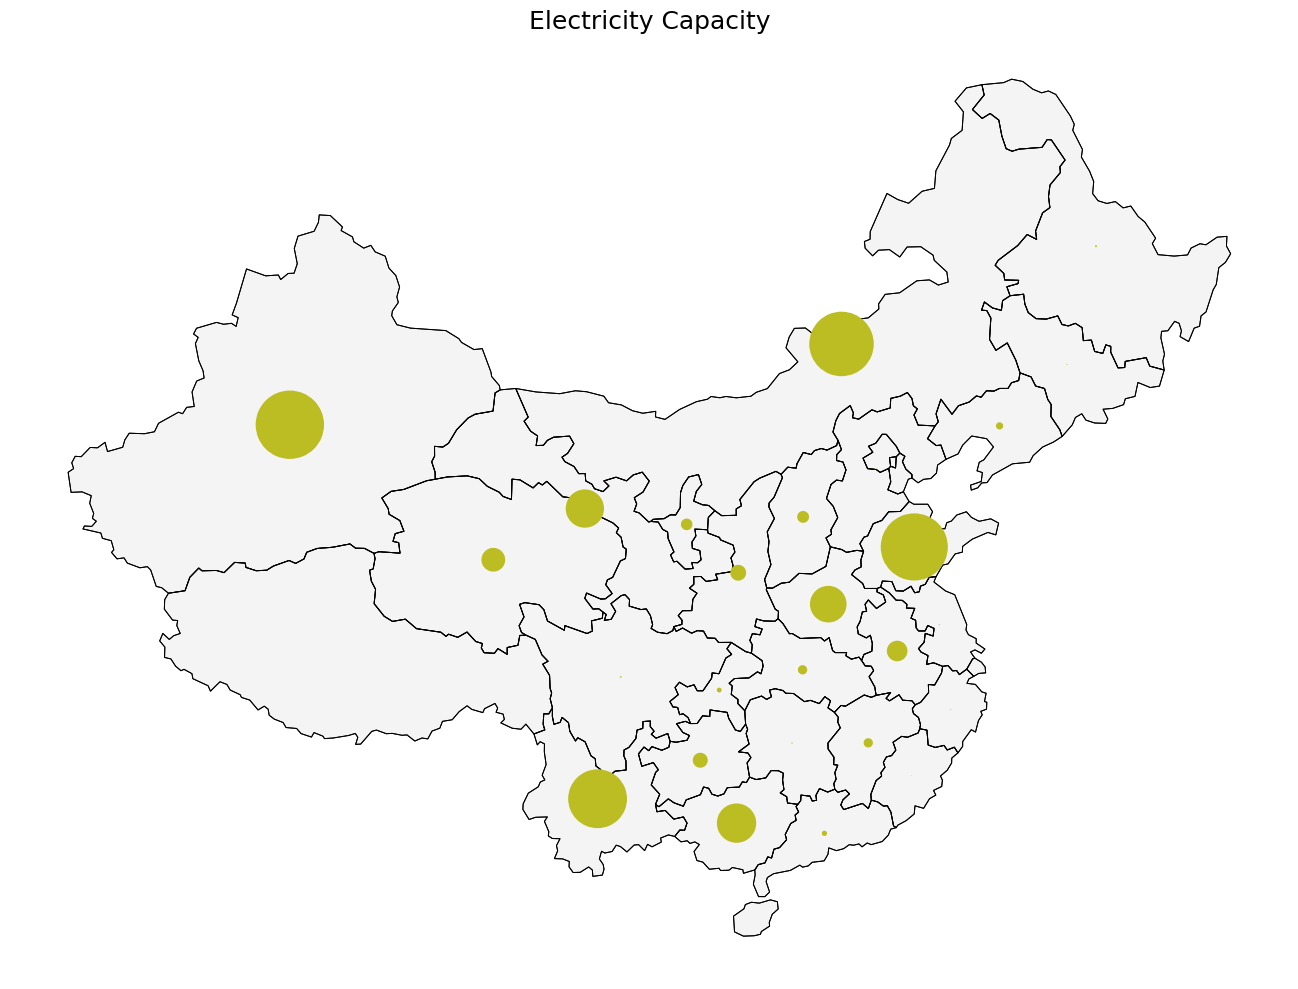

In [73]:
elec_df, cement_df, steel_df, aluminum_df = get_capacity_by_sector(capacity_dfs, "noemissionscap")

plot_province_pies(gdf, aluminum_df,     colors=custom_color_map, pie_scale=2.5,   title="Electricity Capacity")


In [76]:
elec_df

,Hydropower,Solar PV (Centralized),Solar PV (Distributed),Wind (Offshore),Wind (Onshore),Battery Storage,Natural Gas Power,Nuclear,Pumped Hydro Storage
region_name,,,,,,,,,
Anhui,5071.0,0.715221,7.001147e-01,0.000000,0.661186,2.225057,2005.043856,0.000000,4680.0
Beijing,892.0,0.994038,9.731744e-01,0.000000,0.343650,3.708143,11378.927465,0.000000,892.0
Chongqing,5834.0,0.842323,8.031022e-01,0.000000,0.353100,0.536510,868.905786,0.000000,1200.0
Fujian,8922.0,0.847372,7.080874e-01,0.224420,0.411417,2.355868,4024.961929,3509.239537,3800.0
Gansu,5514.0,0.740780,-5.684342e-14,0.000000,0.513427,2.577576,2.421120,0.000000,0.0
Guangdong,12682.0,0.686108,7.378423e-01,0.159429,0.388586,2.486694,24520.238920,6454.444030,10880.0
Guangxi,15330.0,0.637180,-4.547474e-13,0.155304,0.470263,2.612653,143.410819,869.092161,0.0
Guizhou,16735.0,0.688938,-8.526513e-14,0.000000,0.440610,0.535694,2.322908,0.000000,0.0
Hainan,1002.0,0.654456,8.987988e-01,0.326962,0.635704,0.534574,1017.206119,520.158981,600.0
